# GARCH(1,1) Volatility Forecasting

The goal is to implement the GARCH(1,1) volatility model, estimate parameters using maximum likelihood,
and evaluate whether GARCH improves volatility forecasting performance relative to what we've done so far, historical volatility and EWMA models.

# Introduction

The previous notebooks have told us that volatility clusters and is forecastable.

Historical Volatility assumes future volatility resembles past volatility. EWMA improves upon this idea by assigning greater weight to recent observations. However, neither model estimates volatility dynamics from data.

The GARCH model addresses this limitation by treating volatility as a stochastic process whose evolution depends on both previous volatility and previous return shocks.

Now I'd like to see this

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from arch import arch_model

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

plt.style.use("ggplot")

START = "2005-01-01"

In [2]:
spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] /
    spy["Close"].shift(1)
)

spy["rv_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

spy["target_20d"] = (
    spy["rv_20"]
    .shift(-20)
)

spy = spy.dropna()

[*********************100%***********************]  1 of 1 completed


# Understanding GARCH

GARCH stands for Generalized Autoregressive Conditional Heteroskedasticity.

The model assumes that volatility evolves through time according to 

$$σ²ₜ = ω + αr²ₜ₋₁ + βσ²ₜ₋₁$$

where

$ω$ controls long run variance

$α$ measures the impact of recent shocks

$β$ measures volatility persistence

Unlike historical volatility and EWMA the parameters are estimated directly from data. This helps us to adapt statistical properties of return.

# Experiment 1: Estimating the GARCH Model

I would like to know if volatility process can be estimated from historical returns. GARCH parameters are estimated using maximum likelihood estimation. The estimation procedure identifies the
parameters that maximize the probability of observing the return series.

In [3]:
garch = arch_model(
    spy["returns"] * 100,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1
)

garch_results = garch.fit(
    disp="off"
)

print(
    garch_results.summary()
)

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -7133.18
Distribution:                  Normal   AIC:                           14272.4
Method:            Maximum Likelihood   BIC:                           14292.1
                                        No. Observations:                 5359
Date:                Sun, Jun 21 2026   Df Residuals:                     5359
Time:                        11:51:15   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0290  5.559e-03      5.214  1.850e-07 [1.

## Comments

The parameter estimates provide knowledge about volatility dynamics.

Our big $\beta$ indicates that volatility shocks persist through time. 

A big $\alpha$ would indicated new information rapidly affects volatility. 

Based on their respective ranges, I could say both are high. 

# Experiment 2: Parameter Analysis

The estimated parameters provide an economic interpretation of market behaviour. Let's try to understand what they imply.

In [4]:
params = pd.DataFrame(
    {
        "Parameter":
        garch_results.params.index,

        "Estimate":
        garch_results.params.values
    }
)

params

,Parameter,Estimate
0,omega,0.028984
1,alpha[1],0.128293
2,beta[1],0.846907


## Comments

The estimated coefficients describe how volatility evolves through time.

# Experiment 3: Volatility Persistence

Volatility persistence is one of the most important characteristics of financial markets. Persistent volatility implies that high volatility periods tend to remain for sommetime.

In [5]:
alpha = garch_results.params["alpha[1]"]

beta = garch_results.params["beta[1]"]

persistence = alpha + beta

print(
    f"Persistence = {persistence:.4f}"
)

Persistence = 0.9752


## Comments

Persistence is commonly measured using $α + β$. So values close to one indicate highly persistent volatility regimes. Our value of 0.97 implies slow decay of volatility shocks.

# Experiment 4: Estimated Volatility

Let's now see what volatility path the model has. GARCH model produces a conditional volatility estimate for every observation. This represents the model's estimate of market risk through time.

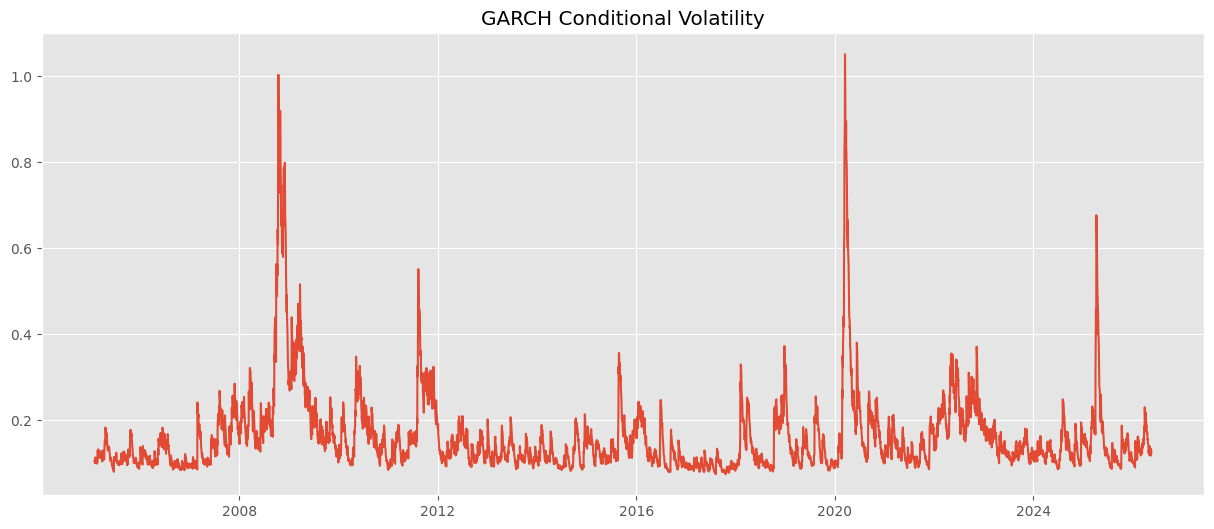

In [6]:
spy["garch_vol"] = (
    garch_results
    .conditional_volatility
    / 100
    * np.sqrt(252)
)

plt.figure(figsize=(15,6))

plt.plot(
    spy.index,
    spy["garch_vol"]
)

plt.title(
    "GARCH Conditional Volatility"
)

plt.savefig("images/nb5_garch_conditional_vol.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

This volatility estimate captures volatility clustering and persistent market stress which wee discussed in notebook1.

# Experiment 5: Comparing Volatility Estimates

Now i'd like to compare the last notebook with this. Since both models capture volatility persistence let's try to see the differences betwen GARCH and EWMA. 

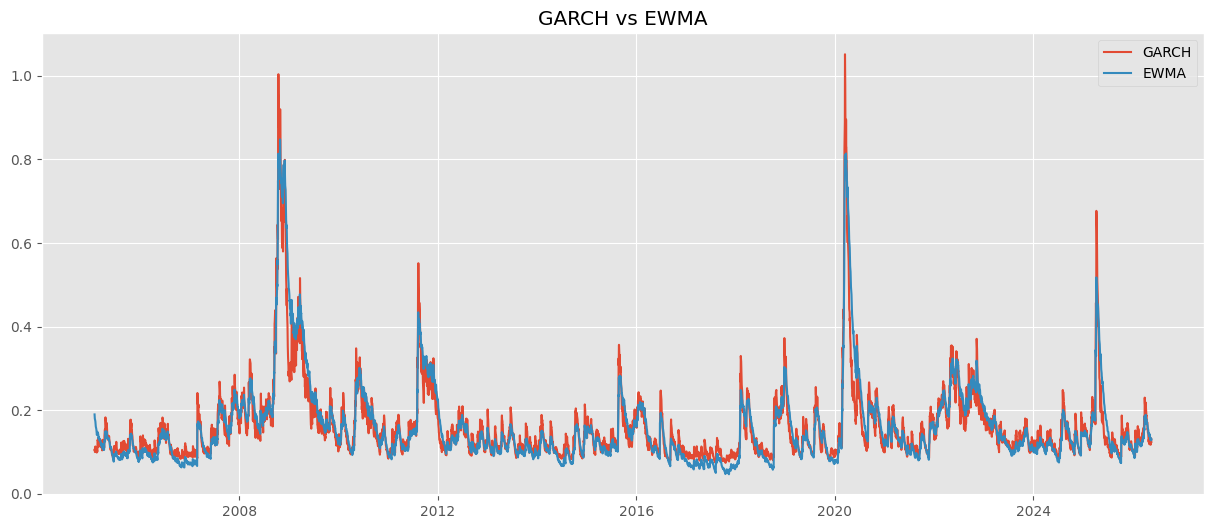

In [7]:
lam = 0.94

returns = spy["returns"]

ewma_var = [returns.var()]

for r in returns.iloc[1:]:

    ewma_var.append(
        lam * ewma_var[-1]
        +
        (1-lam) * r**2
    )

spy["ewma_vol"] = (
    np.sqrt(ewma_var)
    * np.sqrt(252)
)

plt.figure(figsize=(15,6))

plt.plot(
    spy.index,
    spy["garch_vol"],
    label="GARCH"
)

plt.plot(
    spy.index,
    spy["ewma_vol"],
    label="EWMA"
)

plt.legend()

plt.title(
    "GARCH vs EWMA"
)

plt.savefig("images/nb5_garch_vs_ewma.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

The two models produce similar estimates.

Differences arise because GARCH learns its dynamics from data rather than relying on a fixed decay parameter as EWMA.

# Experiment 6: Forecasting Future Volatility

The main goal is not to explain historical volatility, it is to forecast future volatility. Let's see if GARCH can predict future realised volatility. 

In [8]:
forecast = garch_results.forecast(
    horizon=20
)

forecast_variance = (
    forecast
    .variance
    .iloc[-1]
    .mean()
)

forecast_volatility = (
    np.sqrt(forecast_variance)
    / 100
    * np.sqrt(252)
)

print(
    forecast_volatility
)

0.1403903271340838


## Comments

The forecast represents the model's estimate of future market volatility based on current information.

# Experiment 7: Forecast Accuracy

Forecast accuracy provides the primary criterion to evaluate our model.

In [9]:
evaluation_df = spy[
    [
        "target_20d",
        "garch_vol"
    ]
].dropna()

rmse = np.sqrt(
    mean_squared_error(
        evaluation_df["target_20d"],
        evaluation_df["garch_vol"]
    )
)

mae = mean_absolute_error(
    evaluation_df["target_20d"],
    evaluation_df["garch_vol"]
)

pd.DataFrame(
    {
        "Metric":["RMSE","MAE"],
        "Value":[rmse,mae]
    }
)

,Metric,Value
0,RMSE,0.083979
1,MAE,0.051917


## Comments

Remember that for HVF we had RMSE=0.102388 MAE=0.059998 and EWMA we had RMSE=0.088104 MAE=0.053040.
Clearly there is an improvement.

# Case Study: GARCH During the COVID Crisis

As we did for EWMA, let's see if GARCH can perform well during crisis.

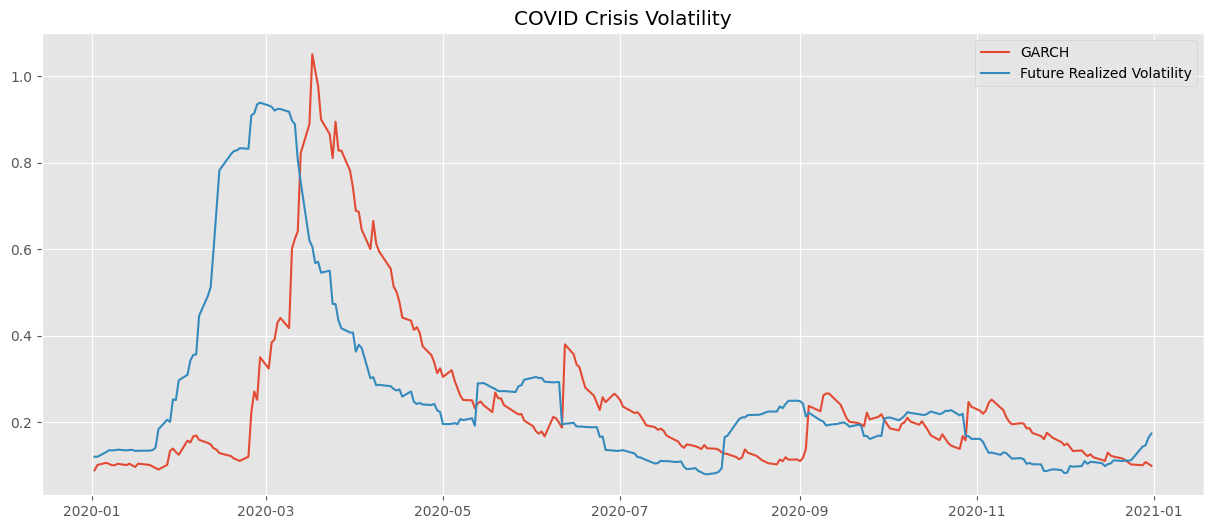

In [10]:
covid = spy.loc[
    "2020-01-01":"2021-01-01"
]

plt.figure(figsize=(15,6))

plt.plot(
    covid.index,
    covid["garch_vol"],
    label="GARCH"
)

plt.plot(
    covid.index,
    covid["target_20d"],
    label="Future Realized Volatility"
)

plt.legend()

plt.title(
    "COVID Crisis Volatility"
)

plt.savefig("images/nb5_covid_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

This does looks better than EWMA. I shall quantify this betterness soon. 

# Experiment 9: Rolling Parameter Estimation

Now lets see if GARCH parameters are stable through time. Because financial markets evolve continuously, so if model parameters change substantially, forecasting performance may also vary.

In [11]:
window = 1000

alphas = []
betas = []
dates = []

for i in range(window, len(spy)):

    sample = (
        spy["returns"]
        .iloc[i-window:i]
        * 100
    )

    model = arch_model(
        sample,
        mean="Zero",
        vol="GARCH",
        p=1,
        q=1
    )

    result = model.fit(
        disp="off"
    )

    alphas.append(
        result.params["alpha[1]"]
    )

    betas.append(
        result.params["beta[1]"]
    )

    dates.append(
        spy.index[i]
    )

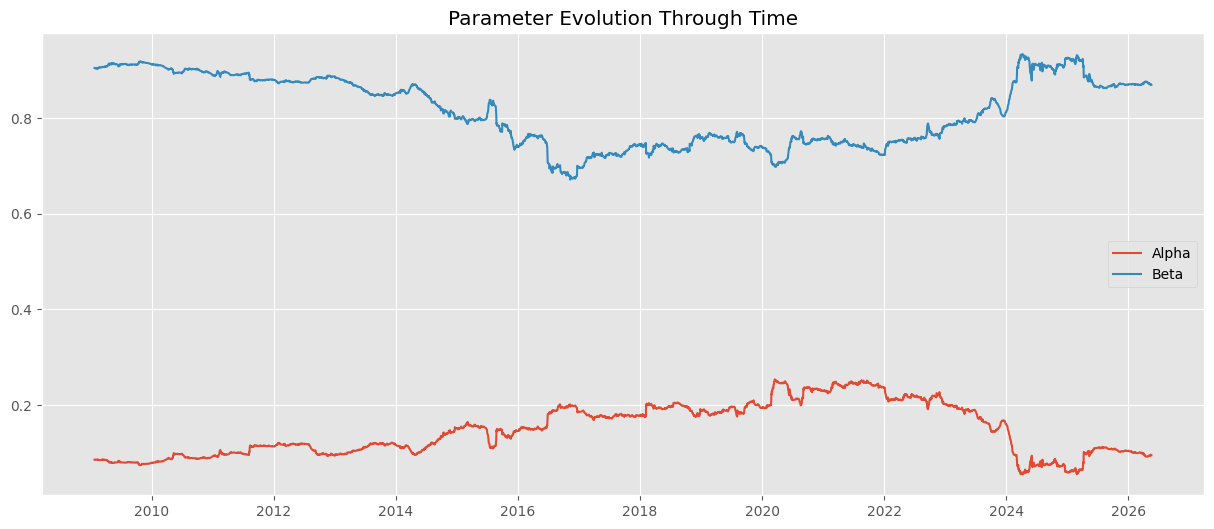

In [12]:
plt.figure(figsize=(15,6))

plt.plot(
    dates,
    alphas,
    label="Alpha"
)

plt.plot(
    dates,
    betas,
    label="Beta"
)

plt.legend()

plt.title(
    "Parameter Evolution Through Time"
)

plt.savefig("images/nb5_parameter_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

Changes in parameter estimates suggest that volatility dynamics evolve through time. This provides evidence that market conditions are not governed by a single setup.

# Conclusions

The GARCH(1,1) model is another framework for modeling volatility. It captures volatility clustering nicely. It seems to perform better than EWMA becuase it learns volatility dynamics directly from data.

This is used in today's world